## 1. Summary

This dataset captures sales transactions from a retail superstore, including order details, customer information, product categories, shipping data, and financial metrics such as sales, profit, discount, and quantity. It provides a comprehensive view of business operations across different regions, segments, and product categories.

The dataset enables analysis of sales performance, profitability trends, customer purchasing behavior, and operational efficiency. It helps identify high-performing products, loss-making segments, and regional demand patterns.

A leading retail company aims to leverage this data to better understand sales dynamics and improve decision-making. The key business question is:
"How can the company use sales data to identify trends, maximize profit, optimize discount strategies, and improve overall business performance?"

## 2. Columns Description

* Row ID → Unique identifier for each transaction
* Order ID → Unique identifier for each order
* Order Date → Date when the order was placed
* Ship Date → Date when the order was shipped
* Ship Mode → Shipping method used (e.g., Standard, Second Class)
* Customer ID → Unique identifier for each customer
* Customer Name → Name of the customer
* Segment → Customer segment (Consumer, Corporate, Home Office)
* Country → Country of the customer
* City → City of the customer
* State → State of the customer
* Postal Code → Postal code of the region
* Region → Region (West, East, Central, South)
* Product ID → Unique identifier for each product
* Category → Product category (Furniture, Office Supplies, Technology)
* Sub-Category → Subdivision of product category
* Product Name → Name of the product
* Sales → Revenue generated from the sale
* Quantity → Number of items sold
* Discount → Discount applied to the product
* Profit → Profit earned from the transaction


## 3. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 4. Import Dataset

In [2]:
df = pd.read_excel('/kaggle/input/datasets/mahendrapalsaniya/superstore/Superstore.xlsx')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 5.  Data Preprocessing

In [3]:
df.shape

(9994, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [5]:
# calculating no of null values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [6]:
# converting a float to intiger
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [7]:
df['Postal Code'] = df['Postal Code'].astype(int)
df['Postal Code'].dtypes

dtype('int64')

### -> Data Description

In [8]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


### -> Data Cleaning

In [9]:
# checking duplicates
if df.duplicated().sum() > 0:
    print('duplicate persent')
else:
    print('not present')

not present


## 6. Exploratory Data Analysis (EDA)

#### Customer Analysis
1. segmentation

In [10]:
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820


In [11]:
# Types of customers
customer_type = df['Segment'].unique()
print(customer_type)

['Consumer' 'Corporate' 'Home Office']


In [12]:
# Number of customers in each segment
customer_num = df['Segment'].value_counts().reset_index()
customer_num = customer_num.rename(columns ={'Segment':'customer_type','count':'customer_num'})
print(customer_num)

  customer_type  customer_num
0      Consumer          5191
1     Corporate          3020
2   Home Office          1783


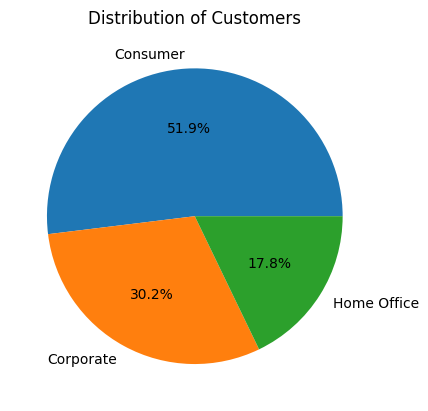

In [13]:
# plotting a pie chart
plt.pie(customer_num['customer_num'], 
        labels=customer_num['customer_type'], 
        autopct='%1.1f%%')

plt.title('Distribution of Customers')
plt.show()



### Customer and sales

In [14]:
sales_per_cat = df.groupby('Segment')['Sales'].sum().reset_index()
sales_per_cat = sales_per_cat.rename(columns = {'Segment':'customer_type','Sales':'Total_Sales'})
sales_per_cat

,customer_type,Total_Sales
0,Consumer,1.161401e+06
1,Corporate,7.061464e+05
2,Home Office,4.296531e+05


Text(0, 0.5, 'Total Sales')

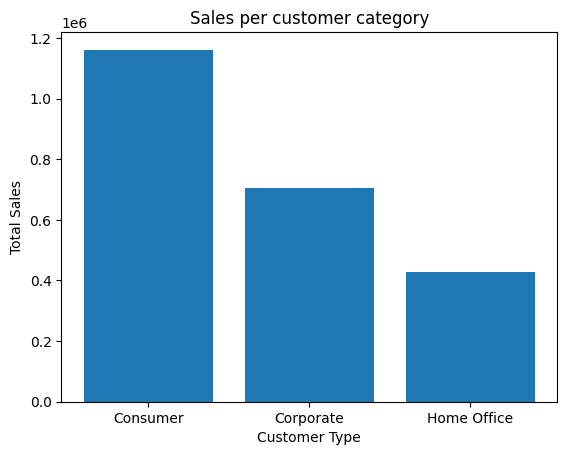

In [15]:
# plot bar graph
plt.bar(sales_per_cat['customer_type'],sales_per_cat['Total_Sales'])

plt.title('Sales per customer category')
plt.xlabel('Customer Type')
plt.ylabel('Total Sales')

In [16]:
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820


### Customer Loyalty
Group data according to : Customer ID,Customer Name,Segment and calculate freq. of their order


In [17]:
# Group data according to : Customer ID,Customer Name,Segment and calculate freq. of their order
customer_order_freq = df.groupby(['Customer ID',
                                  'Customer Name',
                                  'Segment'])['Order ID'].count().reset_index()

#rename order ID coln
customer_order_freq.rename(columns={'Order ID':'Total_Orders'},
                                    inplace=True)

customer_order_freq

,Customer ID,Customer Name,Segment,Total_Orders
0,AA-10315,Alex Avila,Consumer,11
1,AA-10375,Allen Armold,Consumer,15
2,AA-10480,Andrew Allen,Consumer,12
3,AA-10645,Anna Andreadi,Consumer,18
4,AB-10015,Aaron Bergman,Consumer,6
...,...,...,...,...
788,XP-21865,Xylona Preis,Consumer,28
789,YC-21895,Yoseph Carroll,Corporate,8
790,YS-21880,Yana Sorensen,Corporate,12
791,ZC-21910,Zuschuss Carroll,Consumer,31


In [18]:
repeat_cust = customer_order_freq[customer_order_freq['Total_Orders'] > 1]
repeat_cust.sort_values(by='Total_Orders', ascending=False).reset_index(drop=True)

,Customer ID,Customer Name,Segment,Total_Orders
0,WB-21850,William Brown,Consumer,37
1,MA-17560,Matt Abelman,Home Office,34
2,JL-15835,John Lee,Consumer,34
3,PP-18955,Paul Prost,Home Office,34
4,JD-15895,Jonathan Doherty,Corporate,32
...,...,...,...,...
783,EL-13735,Ed Ludwig,Home Office,2
784,SH-20635,Stefanie Holloman,Corporate,2
785,RM-19750,Roland Murray,Consumer,2
786,BO-11425,Bobby Odegard,Consumer,2


### Ranking customers according to Sales

In [19]:
# Ranking
customer_sales = df.groupby(['Customer ID',
                             'Customer Name'])['Sales'].sum().reset_index()

# sort in descending order
customer_sales.sort_values(by='Sales',ascending=False).reset_index(drop=True)

,Customer ID,Customer Name,Sales
0,SM-20320,Sean Miller,25043.050
1,TC-20980,Tamara Chand,19052.218
2,RB-19360,Raymond Buch,15117.339
3,TA-21385,Tom Ashbrook,14595.620
4,AB-10105,Adrian Barton,14473.571
...,...,...,...
788,RS-19870,Roy Skaria,22.328
789,MG-18205,Mitch Gastineau,16.739
790,CJ-11875,Carl Jackson,16.520
791,LD-16855,Lela Donovan,5.304


### Mode of Shipping

In [20]:
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820


In [21]:
# sorting unique values in the ship mode column into a new serise
df['Ship Mode'].unique()

array(['Second Class', 'Standard Class', 'First Class', 'Same Day'],
      dtype=object)

In [22]:
# Freq. use of shipping Methods
shipping_mode = df['Ship Mode'].value_counts().reset_index()

shipping_mode = shipping_mode.rename(columns={'Ship Mode':'Shipping_mode',
                                              'count':'Freq'})
shipping_mode

,Shipping_mode,Freq
0,Standard Class,5968
1,Second Class,1945
2,First Class,1538
3,Same Day,543


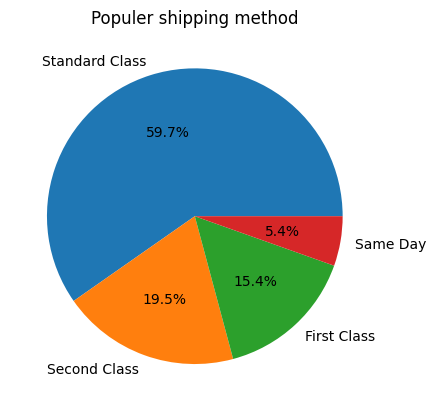

In [23]:
# ploting pie chart
plt.pie(shipping_mode['Freq'],
       labels=shipping_mode['Shipping_mode'],
       autopct='%1.1f%%')

plt.title('Populer shipping method')
plt.show()

In [24]:
# Shipping mode distribution for Tables
tables_df = df[df['Sub-Category'] == 'Tables']
tables_shipping = tables_df['Ship Mode'].value_counts(normalize=True) * 100

# Shipping mode distribution for total dataset
total_shipping = df['Ship Mode'].value_counts(normalize=True) * 100

# Combine into one DataFrame for easy comparison
shipping_compare = pd.DataFrame({
    'Tables (%)': tables_shipping,
    'All Products (%)': total_shipping
}).fillna(0)

print(shipping_compare)

                Tables (%)  All Products (%)
Ship Mode                                   
Standard Class   59.561129         59.715829
Second Class     19.122257         19.461677
First Class      14.733542         15.389234
Same Day          6.583072          5.433260


### Graphical Analysis

In [25]:
# customer by state
state = df['State'].value_counts().reset_index()

state = state.rename(columns={'count':'num_of_customers'})
state.head(10)

,State,num_of_customers
0,California,2001
1,New York,1128
2,Texas,985
3,Pennsylvania,587
4,Washington,506
5,Illinois,492
6,Ohio,469
7,Florida,383
8,Michigan,255
9,North Carolina,249


In [26]:
# Customers by city
city = df['City'].value_counts().reset_index()

city = city.rename(columns={'count':'num_of_customers'})
city

,City,num_of_customers
0,New York City,915
1,Los Angeles,747
2,Philadelphia,537
3,San Francisco,510
4,Seattle,428
...,...,...
526,Abilene,1
527,Montebello,1
528,Kissimmee,1
529,Danbury,1


In [27]:
# Salles per State : grouping state and sales
state_sales = df.groupby(['State'])['Sales'].sum().reset_index()

state_sales.sort_values(by='Sales',ascending=False).reset_index(drop=True).head()

,State,Sales
0,California,457687.6315
1,New York,310876.2710
2,Texas,170188.0458
3,Washington,138641.2700
4,Pennsylvania,116511.9140


In [28]:
# Salles per State : grouping city and sales
city_sales = df.groupby(['City'])['Sales'].sum().reset_index()

city_sales.sort_values(by='Sales',ascending=False).reset_index(drop=True).head()

,City,Sales
0,New York City,256368.161
1,Los Angeles,175851.341
2,Seattle,119540.742
3,San Francisco,112669.092
4,Philadelphia,109077.013


### Average & Median Sales + Profit

In [29]:
# Avoid dividing by 0 by replacing 0 sales with NaN for profitability
df_clean = df.copy()
df_clean['Profitability'] = df_clean['Profit'] / df_clean['Sales']
df_clean['Profitability'] = df_clean['Profitability'].replace([float('inf'), -float('inf')], pd.NA)
avg_sales = df_clean['Sales'].mean()
avg_profit = df_clean['Profit'].mean()
profitability_percentage = df_clean['Profit'].sum() / df_clean['Sales'].sum()

med_sales = df_clean['Sales'].median()
med_profit = df_clean['Profit'].median()
median_percentage = df_clean['Profitability'].median()

print("Averages for Entire Dataset:")
print(f"Average Sales:        ${avg_sales:.2f}")
print(f"Average Profit:       ${avg_profit:.2f}")
print(f"Overall Profitability: {profitability_percentage:.3f}")

print("\nMedians for Entire Dataset:")
print(f"Median Sales:         ${med_sales:.2f}")
print(f"Median Profit:        ${med_profit:.2f}")
print(f"Median Profitability: {median_percentage:.3f}")

Averages for Entire Dataset:
Average Sales:        $229.86
Average Profit:       $28.66
Overall Profitability: 0.125

Medians for Entire Dataset:
Median Sales:         $54.49
Median Profit:        $8.67
Median Profitability: 0.270


### product Analysis

In [30]:
# Types of product Categories
df['Category'].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [31]:
# group data by product category
subcategory_count = df.groupby('Category')['Sub-Category'].nunique().reset_index()

subcategory_count = subcategory_count.sort_values(by='Sub-Category',ascending=False)

subcategory_count.reset_index(drop=True)

,Category,Sub-Category
0,Office Supplies,9
1,Furniture,4
2,Technology,4


### Sales per product category

In [32]:
category_sales = df.groupby(['Category'])['Sales'].sum().reset_index()

category_sales = category_sales.sort_values(by='Sales',ascending=False)
category_sales.reset_index(drop=True)

,Category,Sales
0,Technology,836154.0330
1,Furniture,741999.7953
2,Office Supplies,719047.0320


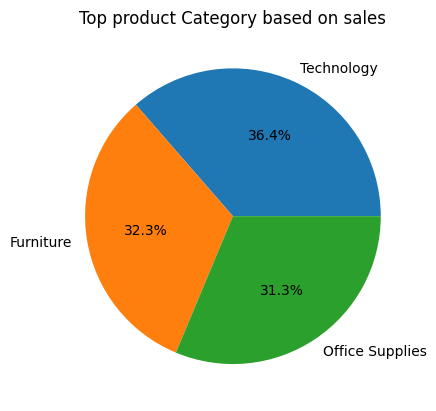

In [33]:
# ploting pie chart
plt.pie(category_sales['Sales'],
       labels=category_sales['Category'],
       autopct='%1.1f%%')

plt.title('Top product Category based on sales')
plt.show()

### Sales per Product

In [34]:
# group data by product sub-category vs sales
pdt_subcategory = df.groupby(['Sub-Category'])['Sales'].sum().reset_index()

# sorting
pdt_subcategory = pdt_subcategory.sort_values(by='Sales', ascending=False)
pdt_subcategory.reset_index(drop=True)

,Sub-Category,Sales
0,Phones,330007.0540
1,Chairs,328449.1030
2,Storage,223843.6080
3,Tables,206965.5320
4,Binders,203412.7330
5,Machines,189238.6310
6,Accessories,167380.3180
7,Copiers,149528.0300
8,Bookcases,114879.9963
9,Appliances,107532.1610


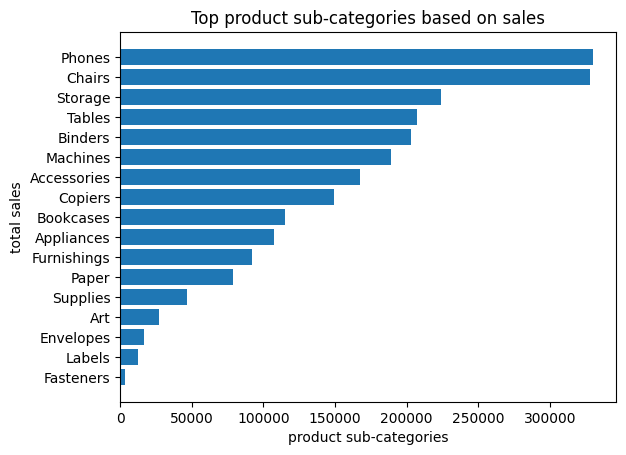

In [35]:
# sorting
pdt_subcategory = pdt_subcategory.sort_values(by='Sales', ascending=True)


# Ploting bar graph
plt.barh(pdt_subcategory['Sub-Category'],
       pdt_subcategory['Sales'])

plt.title('Top product sub-categories based on sales')
plt.xlabel('product sub-categories')
plt.ylabel('total sales')
plt.show()

### Sub Categories by Profit

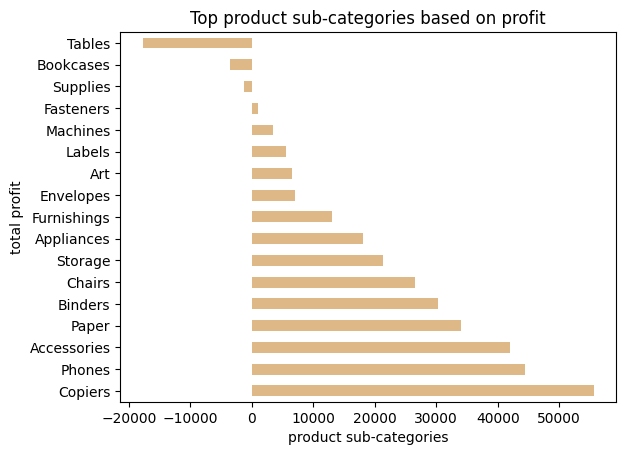

In [36]:
colors = ['burlywood', 'burlywood', 'burlywood', 'burlywood', 'burlywood', 'burlywood', 'burlywood', 'burlywood', 'burlywood', 'burlywood',
         'burlywood', 'burlywood', 'burlywood', 'burlywood', 'burlywood', 'burlywood', 'burlywood', 'darkorange', 'darkorange', 'darkorange']
df_sub = df.groupby('Sub-Category')['Profit'].sum()
df_sub.sort_values(ascending=False).plot.barh(color = colors);
plt.title('Top product sub-categories based on profit')
plt.xlabel('product sub-categories')
plt.ylabel('total profit')
plt.show()

### Sales Trade Analysis

In [37]:
# convert order-date to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'],dayfirst=True)

#grouping by years and summing the sales per year
yearly_sales = df.groupby(df['Order Date'].dt.year)['Sales'].sum().reset_index()

# setting new index and renaming columns
yearly_sales = yearly_sales.rename(columns={'Order Date':'Year', 'Sales':'Total_sales'})
yearly_sales

,Year,Total_sales
0,2014,484247.4981
1,2015,470532.5090
2,2016,609205.5980
3,2017,733215.2552


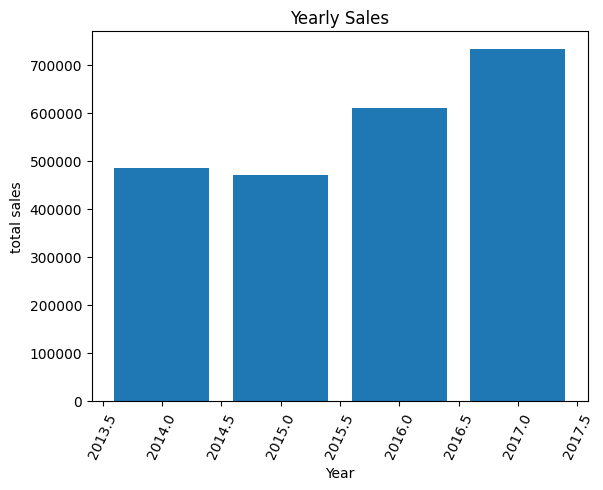

In [38]:
# Ploting bar graph

plt.bar(yearly_sales['Year'],
       yearly_sales['Total_sales'])

plt.title('Yearly Sales')
plt.xlabel('Year')
plt.ylabel('total sales')

plt.xticks(rotation = 65)
plt.show() 

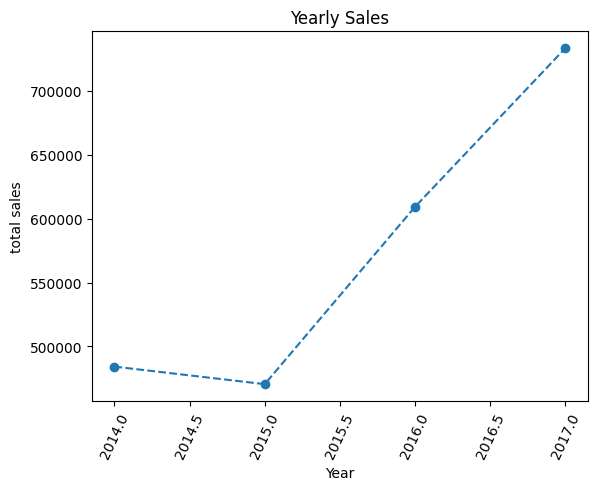

In [39]:
# Ploting a Line graph

plt.plot(yearly_sales['Year'],
       yearly_sales['Total_sales'],
        marker='o',
        linestyle='--')

plt.title('Yearly Sales')
plt.xlabel('Year')
plt.ylabel('total sales')

plt.xticks(rotation = 65)
plt.show()

#### Top 20 States By Sales

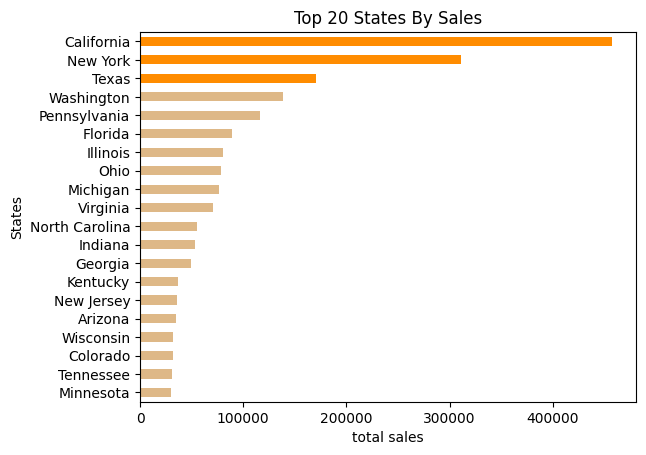

In [40]:
sales_df = df.groupby('State')['Sales'].sum().sort_values(ascending=True)
sales_df.tail(20).plot.barh(color = colors);
plt.xlabel('total sales')
plt.ylabel('States')
plt.title('Top 20 States By Sales')
plt.show()

### Top 20 States by Profitability

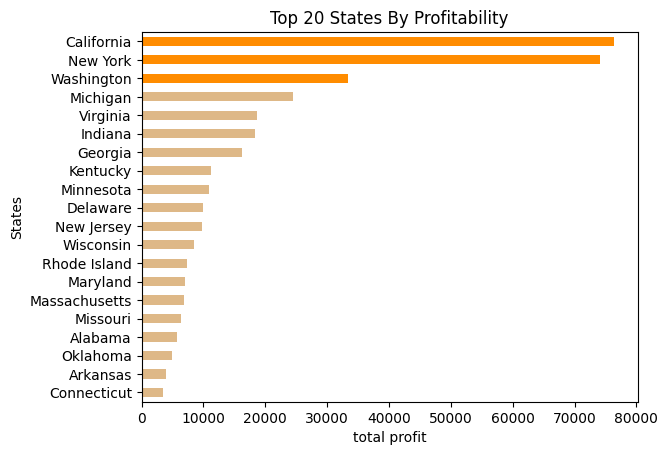

In [41]:
df_state = df.groupby('State')['Profit'].sum()
df_state.sort_values(ascending=True).tail(20).plot.barh(color=colors);
plt.xlabel('total profit')
plt.ylabel('States')
plt.title('Top 20 States By Profitability')
plt.show()

### Top 20 Cities by Sale

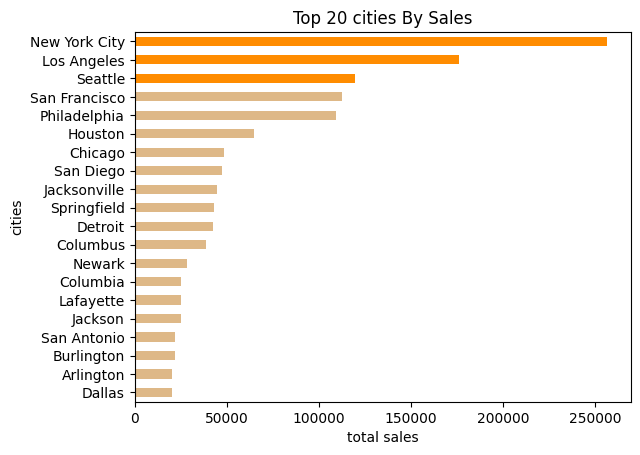

In [42]:
df_sale = df.groupby('City')['Sales'].sum()
df_sale.sort_values(ascending=True).tail(20).plot.barh(color=colors);
plt.xlabel('total sales')
plt.ylabel('cities')
plt.title('Top 20 cities By Sales')
plt.show()

### Top 20 Cities by Profit

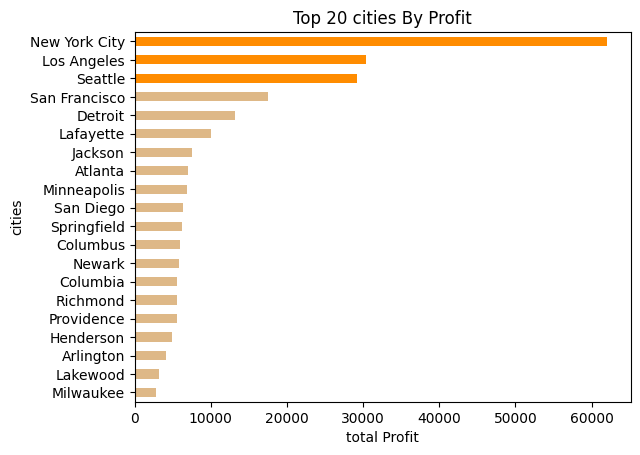

In [43]:
df_pro = df.groupby('City')['Profit'].sum()
df_pro.sort_values(ascending=True).tail(20).plot.barh(color=colors);
plt.xlabel('total Profit')
plt.ylabel('cities')
plt.title('Top 20 cities By Profit')
plt.show()

### Most and Least Profitiable Cities

In [44]:
# Calculate total sales and profit per city
city_ps = df.groupby('City')[['Sales', 'Profit']].sum()

# Calculate profitability
city_ps['Profitability'] = city_ps['Profit'] / city_ps['Sales']

#Dropping cities with 0 profitability 
city_ps = city_ps[city_ps['Profitability'] > 0]

city_sorted = city_ps.sort_values('Profitability', ascending=False)

top_10 = city_sorted.head(10)
bottom_10 = city_sorted.tail(10)

print("Top 10 Cities by Profitability:")
print(top_10[['Sales', 'Profit', 'Profitability']])

print("\nBottom 10 Cities by Profitability:")
print(bottom_10[['Sales', 'Profit', 'Profitability']])

Top 10 Cities by Profitability:
                Sales    Profit  Profitability
City                                          
Atlantic City   23.36   11.6800       0.500000
Grand Island    15.96    7.9800       0.500000
New Brunswick   14.77    7.1567       0.484543
Summerville    406.94  196.9132       0.483888
Holland        137.86   66.6588       0.483525
Antioch         19.44    9.3312       0.480000
Lindenhurst     55.48   26.6304       0.480000
Davis           32.40   15.5520       0.480000
Royal Oak       35.34   16.9632       0.480000
Bozeman         43.66   20.8106       0.476651

Bottom 10 Cities by Profitability:
                      Sales    Profit  Profitability
City                                                
Miramar           1531.1920   32.2810       0.021082
Port Saint Lucie   248.9500    4.4490       0.017871
Huntsville        9194.9868  161.8308       0.017600
Hillsboro           87.8380    1.5455       0.017595
Johnson City       765.8480   11.8562       0.0154

#### Sales and Profitability Analysis Across Cities
The dataset shows an average sales of USD 229.86 and an average profit of USD 28.66, with an overall profitability ratio of 0.125. Median values (sales: USD 54.49, profit: USD 8.67, profitability: 0.270) suggest a skewed distribution, where a few high-sales cities raise the averages.

#### Top 10 Cities by Profitability:
Cities such as Atlantic City and Grand Island have moderate sales but high profitability ratios between 0.48 and 0.50, indicating efficient profit generation. Summerville stands out with high sales and similarly strong profitability near 0.48.

#### Bottom 10 Cities by Profitability:
Cities like Huntsville and Pasadena report large sales but very low profitability ratios below 0.02, highlighting inefficiencies despite high revenue.

#### Conclusion:
High sales do not always equate to high profitability. Considering profitability ratios alongside sales helps guide strategic decisions to improve overall performance.

###  Quarterly Sales of year

In [45]:
# convert order-date to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'],dayfirst=True)

# filter data according to year
year_sales = df[df['Order Date'].dt.year == 2017]

# calculate Quarterly Sales of year 2017
quartely_sales = year_sales.resample('Q',on='Order Date')['Sales'].sum().reset_index()
quartely_sales = quartely_sales.rename(columns={'Order Date':'Quarter','Sales':'total_sales'})

print('This is Quarterly sales for 2017')
quartely_sales

This is Quarterly sales for 2017


,Quarter,total_sales
0,2017-03-31,123144.8602
1,2017-06-30,133764.3720
2,2017-09-30,196251.9560
3,2017-12-31,280054.0670


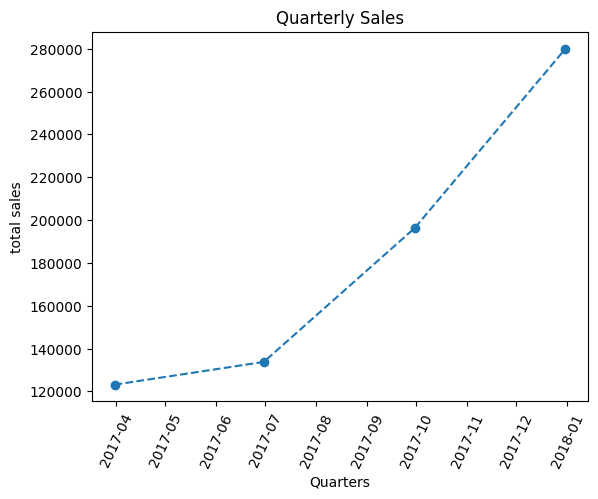

In [46]:
plt.plot(quartely_sales['Quarter'],
       quartely_sales['total_sales'],
        marker='o',
        linestyle='--')

plt.title('Quarterly Sales')
plt.xlabel('Quarters')
plt.ylabel('total sales')

plt.xticks(rotation = 65)
plt.show()

### Monthly sales trend for year

In [47]:
# convert order-date to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'],dayfirst=True)

# filter data according to year
year_sales = df[df['Order Date'].dt.year == 2017] 

monthly_sales = year_sales.resample('M',on='Order Date')['Sales'].sum().reset_index()
monthly_sales = monthly_sales.rename(columns={'Order Date':'Month','Sales':'total_sales'})

print('This is Monthly sales for 2017')
monthly_sales

This is Monthly sales for 2017


,Month,total_sales
0,2017-01-31,43971.3740
1,2017-02-28,20301.1334
2,2017-03-31,58872.3528
3,2017-04-30,36521.5361
4,2017-05-31,44261.1102
5,2017-06-30,52981.7257
6,2017-07-31,45264.4160
7,2017-08-31,63120.8880
8,2017-09-30,87866.6520
9,2017-10-31,77776.9232


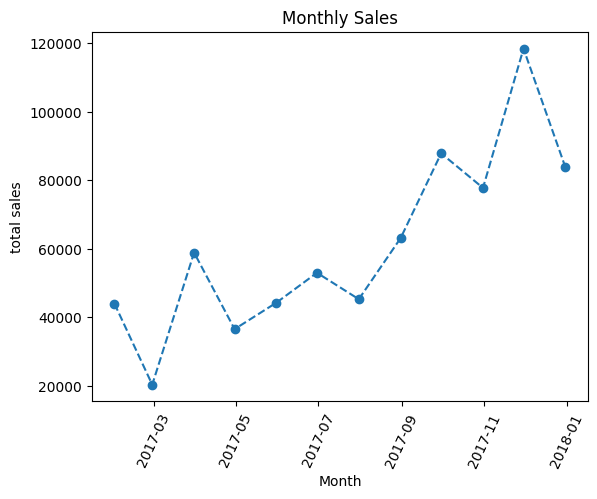

In [48]:
plt.plot(monthly_sales['Month'],
       monthly_sales['total_sales'],
        marker='o',
        linestyle='--')

plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('total sales')

plt.xticks(rotation = 65)
plt.show()

#### Analysis of Top Customers and Profitability Across Customer Segments
This analysis examines the average profit generated across different customer segments to investigate potential relationships between segmentation and profitability. Additionally, the Pareto Principle (80/20 Rule) is applied to determine whether a small subset of customers accounts for the majority of total profit.

### Top 20 Customers by Profit

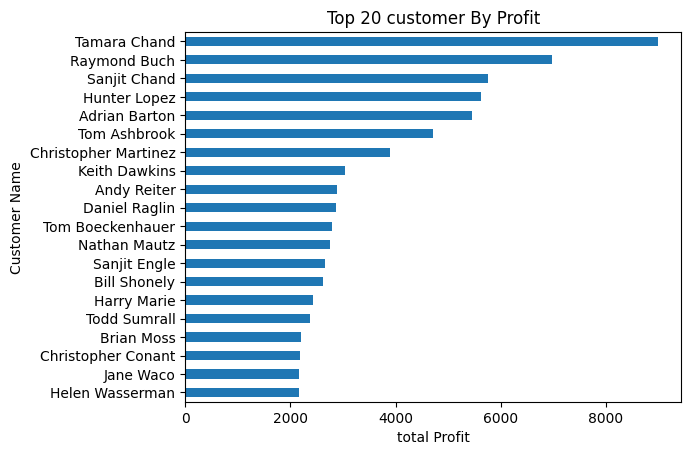

In [49]:
df_cust = df.groupby('Customer Name')['Profit'].sum()
df_cust.sort_values(ascending=True).tail(20).plot.barh();
plt.xlabel('total Profit')
plt.ylabel('Customer Name')
plt.title('Top 20 customer By Profit')
plt.show()

### Average Profit by Customer Segment

Segment
Home Office    33.818664
Corporate      30.456667
Consumer       25.836873
Name: Profit, dtype: float64


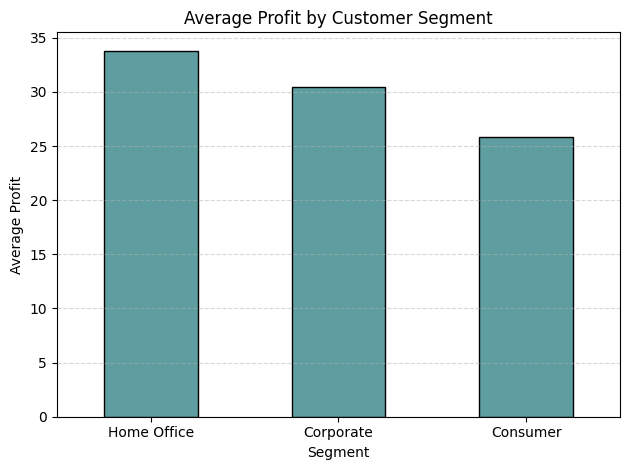

In [50]:
# Group by Segment and calculate average profit
avg_profit_by_segment = df.groupby('Segment')['Profit'].mean().sort_values(ascending=False)

print(avg_profit_by_segment)

#plotting the results 
avg_profit_by_segment.plot(kind='bar', color='cadetblue', edgecolor='black')
plt.title('Average Profit by Customer Segment')
plt.ylabel('Average Profit')
plt.xlabel('Segment')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Applying Pareto Principle to customers and profit

In [51]:
df2 = pd.DataFrame(df.groupby('Customer Name')['Profit'].sum()
                    .sort_values(ascending=False))

df2.quantile(0.7, interpolation='higher')

Profit    463.269
Name: 0.7, dtype: float64

In [52]:
df2[df2['Profit']>=463.269].sum()/df['Profit'].sum()

Profit    0.971351
dtype: float64

### Customer Profitability Analysis
The analysis reveals that the **top 30% of customers account for approximately 97% of total profit**. This significant concentration of profitability highlights the importance of **prioritizing relationship management, personalized engagement, and retention strategies** for these high-value customers in order to drive sustained business growth and long-term profitability

### Evaluation of Product Sub-Categories Based on Sales and Profit Performance
This analysis aims to assess product sub-categories by examining both their sales volumes and profitability metrics. The objective is to:

* Identify high-performing segments that contribute significantly to revenue and profit growth.
* Highlight underperforming or unprofitable categories that may necessitate strategic review and corrective actions.

##  Sales vs Profitability Insights
The visualizations indicate that while sub-categories such as **Copiers, Paper**, and **Accessories** do not rank among the top three in sales, they consistently appear among the top four in terms of profitability. This suggests these products benefit from **strong profit margins** and presents a strategic opportunity for the company to **scale these sub-categories** particularly **Paper** to further enhance overall profitability.

In contrast, **Tables**, despite generating the **fourth-highest sales**, incurs **significant losses**. Since shipping costs have been ruled out as a major contributor, the discrepancy likely stems from **aggressive discounting** or other internal pricing factors. Further investigation is warranted to determine the root causes and identify appropriate corrective actions.

## Shipping prices for tables vs all products

### Analysis of Shipping Mode and Profitability in Product Sub-Categories
The analysis reveals minimal variation in shipping mode distribution between Tables and other product categories, indicating that shipping method is unlikely to be the primary driver of lower profitability. This suggests that excessive discounting may be a significant factor contributing to the negative profit performance of this sub-category and warrants further investigation.

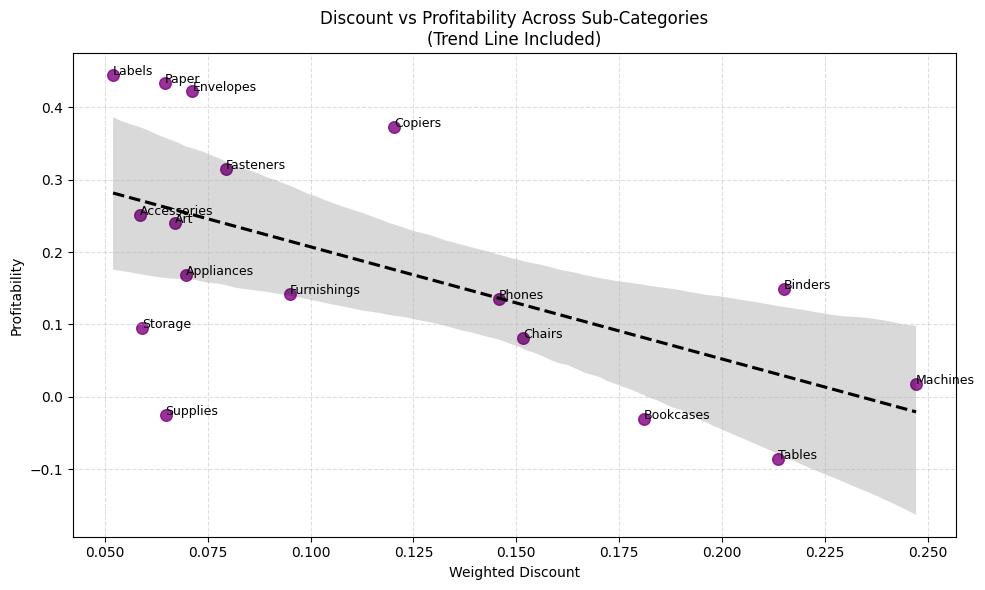

In [53]:
# Group by Sub-Category and compute metrics
grouped = df.groupby('Sub-Category').apply(
    lambda g: pd.Series({
        'Weighted Discount': (g['Discount'] * g['Sales']).sum() / g['Sales'].sum(),
        'Profitability': g['Profit'].sum() / g['Sales'].sum()
    })
).reset_index()

# Plot with regression line
plt.figure(figsize=(10, 6))
sns.regplot(
    data=grouped,
    x='Weighted Discount',
    y='Profitability',
    scatter_kws={'s': 70, 'color': 'purple'},
    line_kws={'color': 'black', 'linestyle': '--'}
)

# Annotate sub-category names
for _, row in grouped.iterrows():
    plt.text(row['Weighted Discount'], row['Profitability'], row['Sub-Category'], fontsize=9)

plt.title('Discount vs Profitability Across Sub-Categories\n(Trend Line Included)')
plt.xlabel('Weighted Discount')
plt.ylabel('Profitability')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 7.  Discount vs Profitability Analysis
The scatter plot titled **“Discount vs Profitability Across Sub-Categories”** reveals a clear negative correlation between weighted discount and profitability. In general, as discount rates increase, profitability tends to decline across most sub-categories.

Sub-categories such as **Labels**, **Paper**, **Envelopes**, and **Copiers** demonstrate high profitability with relatively low average discounts, indicating strong margins and effective pricing strategies.

**Tables** is the **least profitable sub-category**, despite ranking among the top in sales volume. It also has one of the highest average discounts. Given that shipping costs have been ruled out as a major factor, this suggests that **aggressive discounting is the primary driver of its negative profitability**, highlighting a need for immediate review of its pricing strategy.

**Machines** and **Bookcases** show similar patterns, with high discounts and low to negative profitability, making them additional candidates for strategic pricing reassessment.

**Binders**, while subject to relatively high discounts, still maintains moderate profitability. This is likely due to **its lower cost structure**, allowing it to absorb discounts more effectively without significantly impacting margins.


## 8. Conclusion
This analysis reinforces that excessive discounting can erode profit margins, especially for higher-cost items. To improve overall profitability, it is essential to reevaluate pricing and discounting strategies—particularly for **Tables**, which exhibits the most significant loss despite high sales performance.
